In [3]:
import numpy as np
import torch
import matplotlib.pyplot as plt
import os
from funciones.cargador import obtener_una_muestra, DATA_DIR

In [2]:
def detector_fase_transitorio(iq_tensor: torch.Tensor, window_size: int = 100, tau: float = 5.0, consecutives: int = 5):
    """
    Algoritmo de Detección de Fase (PD) para identificar el transitorio de señales RF.
    
    Args:
        iq_tensor: Tensor [2, N] con los canales I y Q.
        window_size: Tamaño de la ventana temporal para el cálculo de la varianza.
        tau: Umbral de la trayectoria fractal (diferencia de varianzas).
        consecutives: Número de ventanas consecutivas por debajo del umbral para confirmar la ráfaga.
        
    Returns:
        dict: Contiene el índice de inicio detectado, el vector de varianzas y la trayectoria fractal.
    """
    # 1. Extracción de componentes y cálculo de Fase Instantánea
    i_np = iq_tensor[0].numpy()
    q_np = iq_tensor[1].numpy()
    
    # Fase en el rango [-pi, pi]
    fase_inst = np.arctan2(q_np, i_np)
    
    # 2. Desenvolvimiento (Unwrapping) para eliminar discontinuidades de fase
    fase_unwrap = np.unwrap(fase_inst)
    
    # 3. Cálculo de varianza en ventanas temporales (Vectorizado para máxima eficiencia)
    n_muestras = len(fase_unwrap)
    n_ventanas = n_muestras // window_size
    
    # Truncado seguro para reshape exacto
    fase_matriz = fase_unwrap[:n_ventanas * window_size].reshape(n_ventanas, window_size)
    
    # Varianza local por ventana
    varianzas = np.var(fase_matriz, axis=1)
    
    # 4. Trayectoria Fractal (Diferencia absoluta entre varianzas consecutivas)
    diff_varianzas = np.abs(np.diff(varianzas))
    
    # 5. Lógica de Detección del Transitorio
    condicion = diff_varianzas <= tau
    
    # Búsqueda de 'consecutives' ventanas continuas usando convolución 1D
    kernel = np.ones(consecutives, dtype=int)
    conteo = np.convolve(condicion.astype(int), kernel, mode='valid')
    
    indices_validos = np.where(conteo == consecutives)[0]
    
    idx_inicio_muestra = -1
    if len(indices_validos) > 0:
        # El inicio real es el índice de la primera ventana que cumple la condición
        idx_ventana_inicio = indices_validos[0]
        idx_inicio_muestra = idx_ventana_inicio * window_size
        
    return {
        "inicio_muestra": idx_inicio_muestra,
        "diff_varianzas": diff_varianzas,
        "fase_unwrap": fase_unwrap
    }

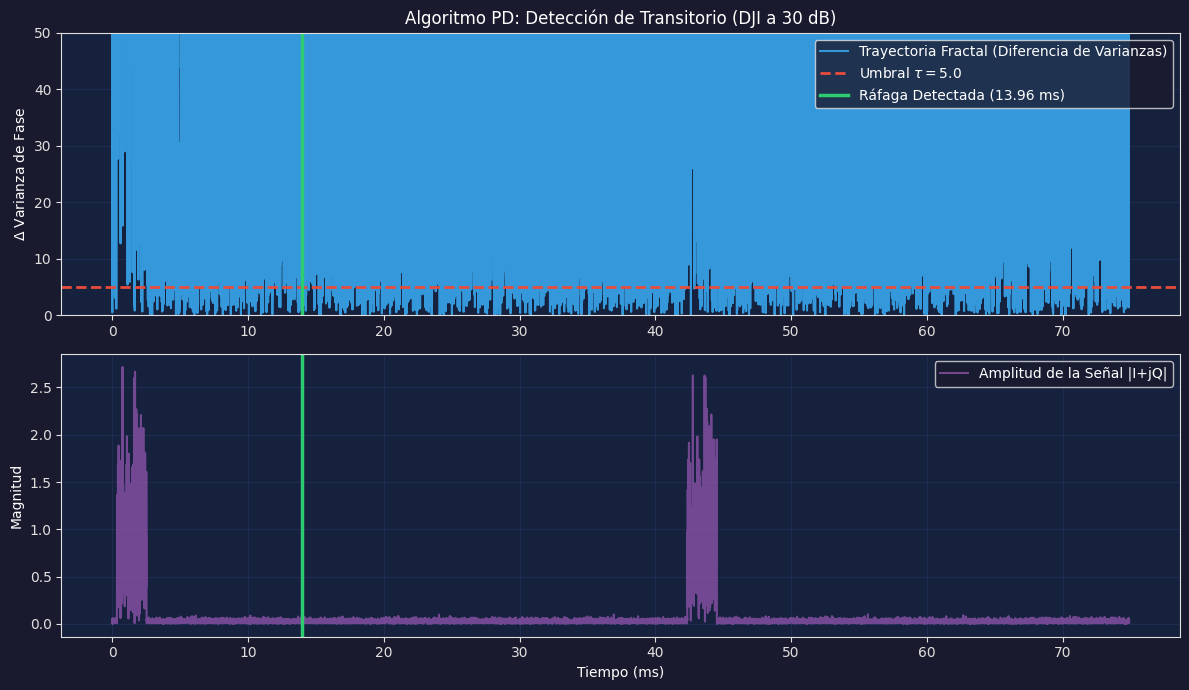

In [6]:
# Seleccionamos una muestra de dron (ej. DJI = 0) a una SNR desafiante
SNR_PRUEBA = 30
TARGET_DRON = 0
WINDOW_SIZE = 100
TAU_UMBRAL = 5.0

# Cargamos la muestra
iq_dron, sample_id, target, snr = obtener_una_muestra(DATA_DIR, target=TARGET_DRON, snr=SNR_PRUEBA)

# Ejecutamos el algoritmo PD
resultados_pd = detector_fase_transitorio(iq_dron, window_size=WINDOW_SIZE, tau=TAU_UMBRAL)

inicio_detectado = resultados_pd["inicio_muestra"]
diff_vars = resultados_pd["diff_varianzas"]

# ==============================================================================
# Configuración del gráfico profesional (Calidad TFM)
# ==============================================================================
plt.figure(figsize=(12, 7), facecolor='#1a1a2e')
ax1 = plt.subplot(2, 1, 1)
ax1.set_facecolor('#16213e')
ax1.tick_params(colors='#e0e0e0')
for spine in ax1.spines.values(): spine.set_color('#e0e0e0')

# Eje temporal en milisegundos (14 MHz de Frecuencia de Muestreo)
fs = 14e6 
eje_tiempo_ms = np.arange(len(diff_vars)) * WINDOW_SIZE / fs * 1000

ax1.plot(eje_tiempo_ms, diff_vars, color='#3498db', linewidth=1.5, label='Trayectoria Fractal (Diferencia de Varianzas)')
ax1.axhline(y=TAU_UMBRAL, color='#e74c3c', linestyle='--', linewidth=2, label=f'Umbral $\\tau={TAU_UMBRAL}$')

if inicio_detectado != -1:
    tiempo_inicio_ms = inicio_detectado / fs * 1000
    ax1.axvline(x=tiempo_inicio_ms, color='#2ecc71', linestyle='-', linewidth=2.5, label=f'Ráfaga Detectada ({tiempo_inicio_ms:.2f} ms)')

ax1.set_title(f'Algoritmo PD: Detección de Transitorio (DJI a {SNR_PRUEBA} dB)', color='white', fontsize=12)
ax1.set_ylabel('$\Delta$ Varianza de Fase', color='white')
ax1.set_ylim(0, 50) # Limitamos el eje Y para ver bien el cruce del umbral
ax1.grid(color='#2c3e6b', alpha=0.4)
ax1.legend(facecolor='#1a1a2e', edgecolor='#e0e0e0', labelcolor='white', loc='upper right')

# Subplot 2: Representación de la envolvente temporal para contrastar
ax2 = plt.subplot(2, 1, 2, sharex=ax1)
ax2.set_facecolor('#16213e')
ax2.tick_params(colors='#e0e0e0')
for spine in ax2.spines.values(): spine.set_color('#e0e0e0')

amplitud = np.sqrt(iq_dron[0].numpy()**2 + iq_dron[1].numpy()**2)
eje_tiempo_amp_ms = np.arange(len(amplitud)) / fs * 1000

# Submuestreamos la amplitud para graficar rápido
step = 100
ax2.plot(eje_tiempo_amp_ms[::step], amplitud[::step], color='#9b59b6', alpha=0.7, label='Amplitud de la Señal |I+jQ|')

if inicio_detectado != -1:
    ax2.axvline(x=tiempo_inicio_ms, color='#2ecc71', linestyle='-', linewidth=2.5)

ax2.set_xlabel('Tiempo (ms)', color='white')
ax2.set_ylabel('Magnitud', color='white')
ax2.grid(color='#2c3e6b', alpha=0.4)
ax2.legend(facecolor='#1a1a2e', edgecolor='#e0e0e0', labelcolor='white', loc='upper right')

plt.tight_layout()
plt.show()